In [1]:
import analysis_utils as utils
import pandas as pd
import numpy as np
import importlib
import warnings 
warnings.filterwarnings("ignore")
from sklearn.model_selection import GroupShuffleSplit

importlib.reload(utils)
print("Loading Data & Generating Artifacts.")
df, metrics, exp_info = utils.load_data_universal("db/results.sqlite")

df = df[df['Length'] <= 500].copy() # to be safe
df["null"] = 0 
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state= 42)
train_idx, test_idx = next(gss.split(df, groups=df['question_id_external']))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loading Data & Generating Artifacts.
Loading Run: HUV_Benchmark_Optimized (ID: 1)
Train shape: (2699, 29)
Test shape: (1175, 29)


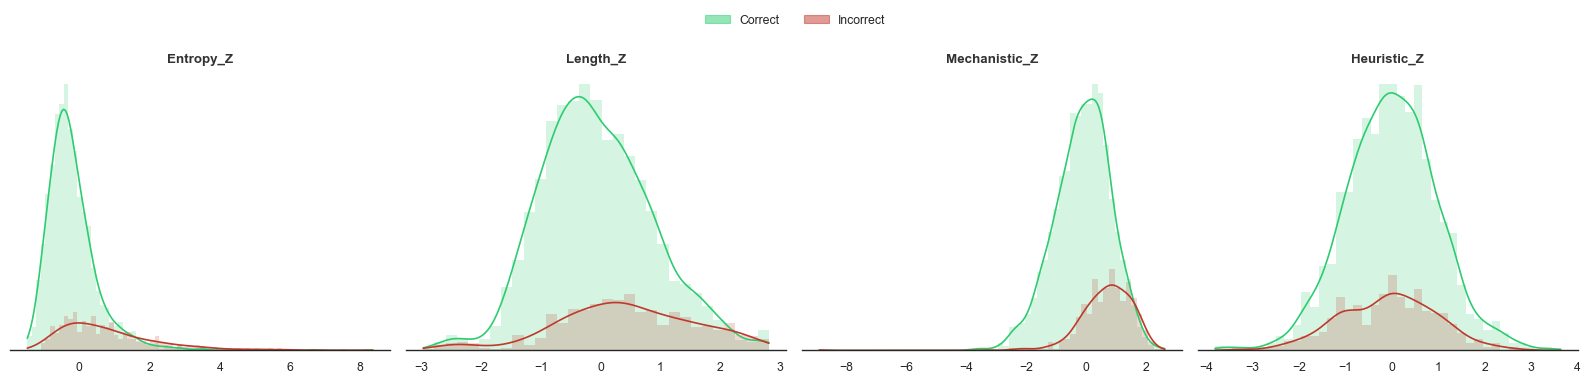

In [2]:

metrics = ['Entropy_Z', 'Length_Z', 'Mechanistic_Z', "Heuristic_Z"]
utils.plot_metric_histograms(train_df, metrics)

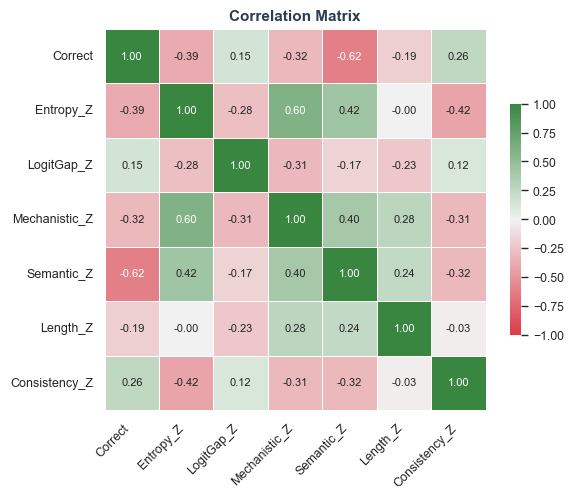

In [4]:
metrics = ['Correct', 'Entropy_Z', 'LogitGap_Z', 'Mechanistic_Z', 'Semantic_Z', 'Length_Z', "Consistency_Z"]
utils.plot_full_correlation_matrix(train_df, metrics)

Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+2.56 SD,0.168,0.159,0.05,
Length,+0.21 SD,294.704,283.850,86.43,
Mechanistic,+1.38 SD,0.979,0.978,0.00,
LogitGap,-0.22 SD,0.022,0.022,0.03,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+0.57 SD,0.077,0.079,0.02,
Length,-0.52 SD,227.112,224.849,45.65,
Mechanistic,+0.47 SD,0.970,0.970,0.00,
LogitGap,+0.13 SD,0.051,0.052,0.05,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis


Generating t-SNE on Train & Test Analysis...


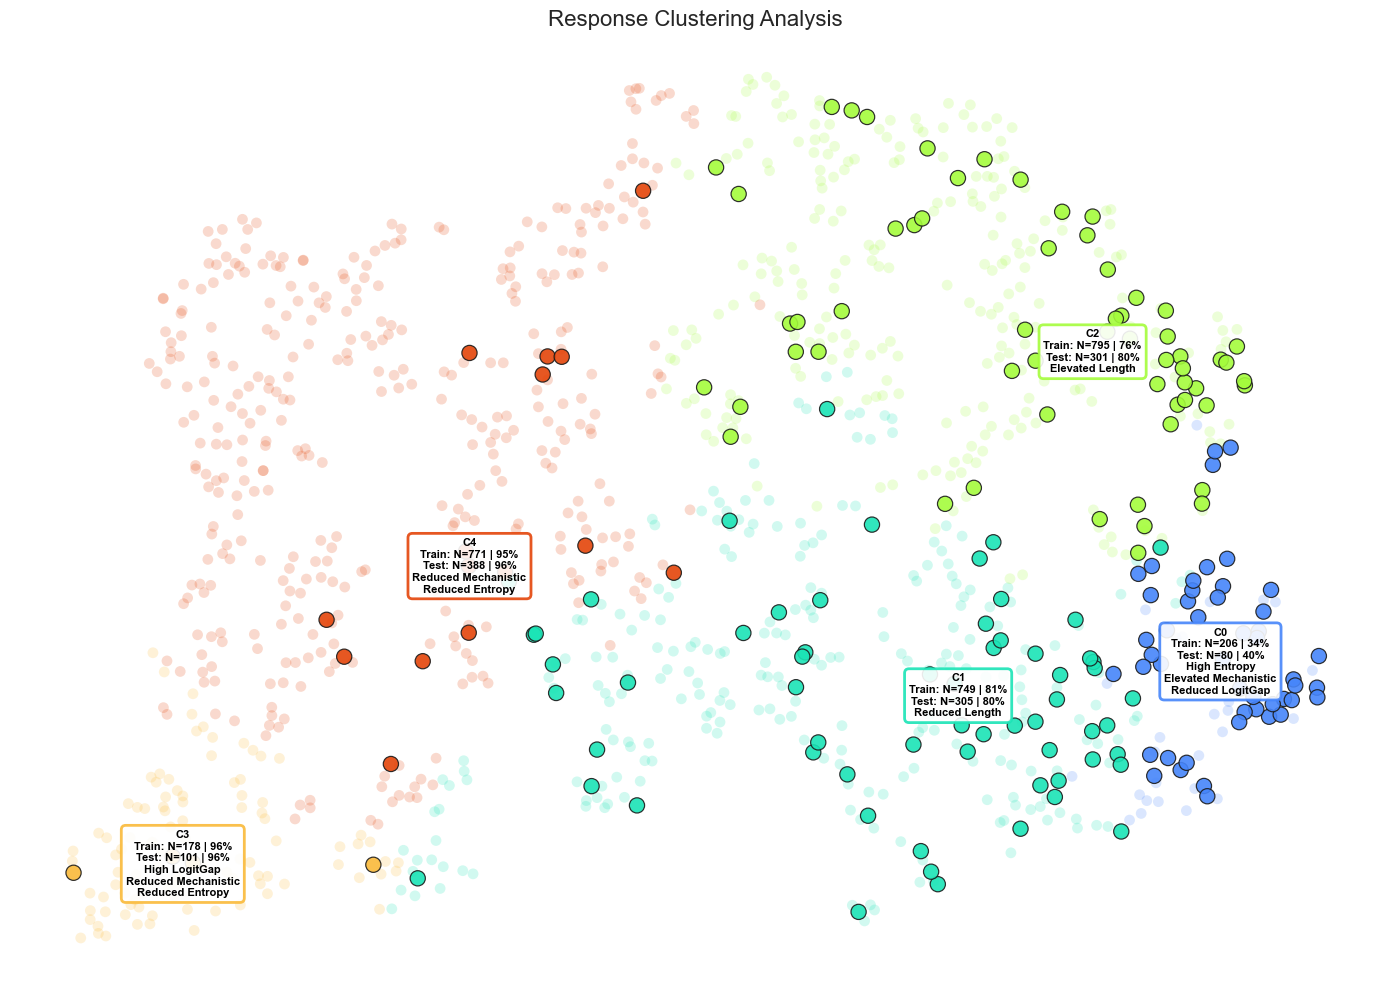

Generating Difficulty Stratification Plots.
Generating Stratified Plots for k=[0, 1, 2, 3, 4]...


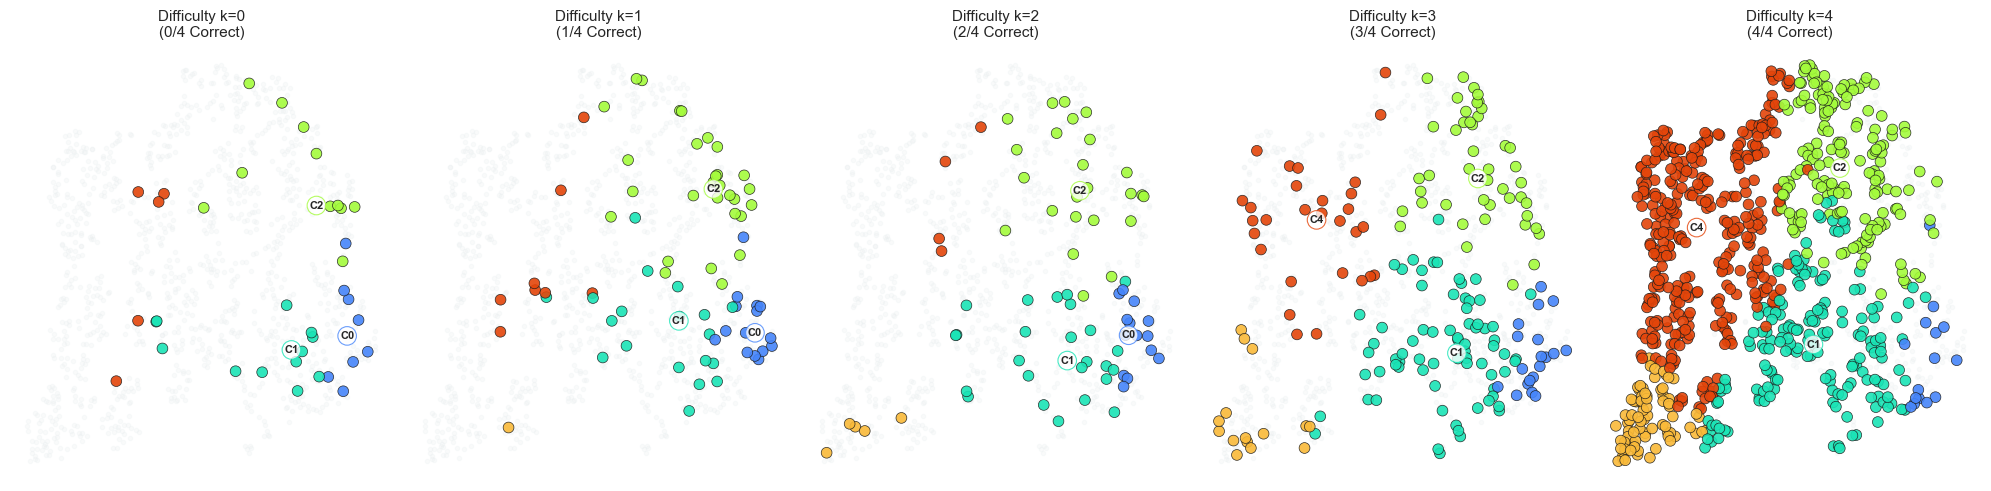

Generating Discrimination Bar Chart.


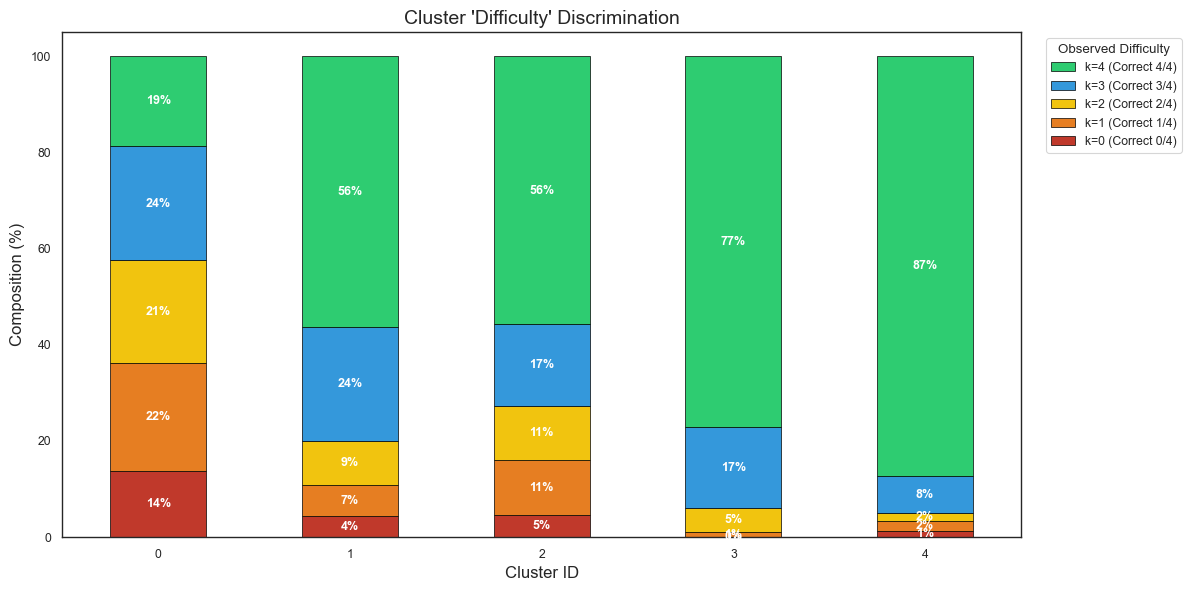


--- Pairwise Cluster Comparison (Same Question Overlap) ---


,Pair,Train_N,Train_Diff,Test_N,Test_Diff
0,C0 (34.5%) vs C1 (80.6%),74,-27.0%,34,-21.6%
1,C0 (34.5%) vs C2 (76.5%),62,-25.0%,25,-27.3%
2,C0 (34.5%) vs C3 (96.1%),7,-71.4%,3,-33.3%
3,C0 (34.5%) vs C4 (95.2%),21,-26.2%,7,-28.6%
4,C1 (80.6%) vs C2 (76.5%),164,-1.4%,61,-5.7%
5,C1 (80.6%) vs C3 (96.1%),62,-4.3%,25,-18.0%
6,C1 (80.6%) vs C4 (95.2%),172,-2.9%,55,-11.8%
7,C2 (76.5%) vs C3 (96.1%),31,-9.7%,15,-13.3%
8,C2 (76.5%) vs C4 (95.2%),101,-4.1%,31,-5.4%
9,C3 (96.1%) vs C4 (95.2%),88,-0.4%,56,-1.8%


In [5]:
cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy", "Length", "Mechanistic", "LogitGap"], test_df = test_df, min_clusters = 5)

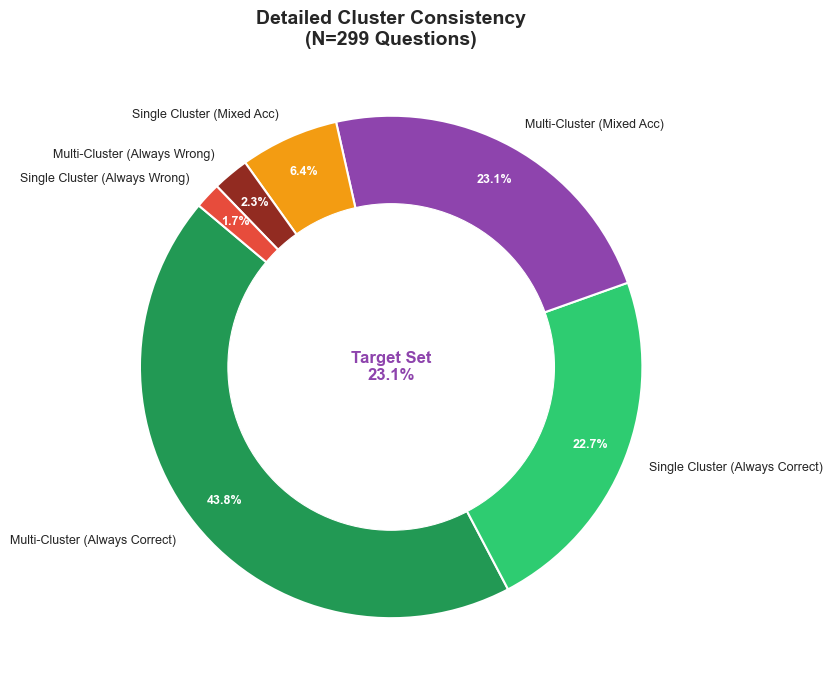

In [6]:
utils.plot_detailed_consistency_pie(test_df, cluster_classifier=cluster_predictor)

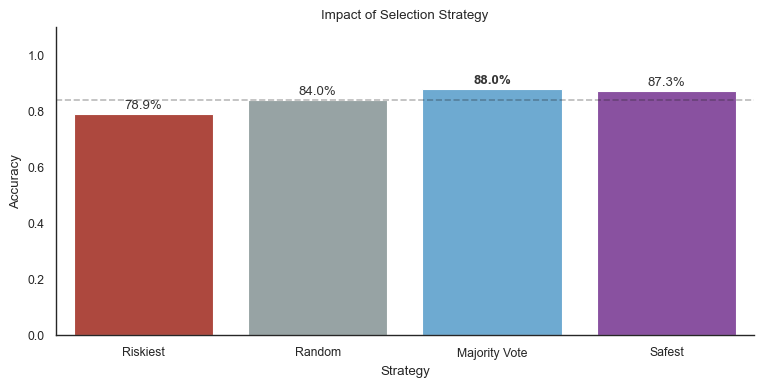

In [7]:
utils.analyze_intra_question_selection(test_df, cluster_predictor)

Category,Questions,%
Excluded: All Correct,131,43.8%
Excluded: Single Cluster,92,30.8%
Kept: Inconsistent Set,69,23.1%
Excluded: All Wrong,7,2.3%


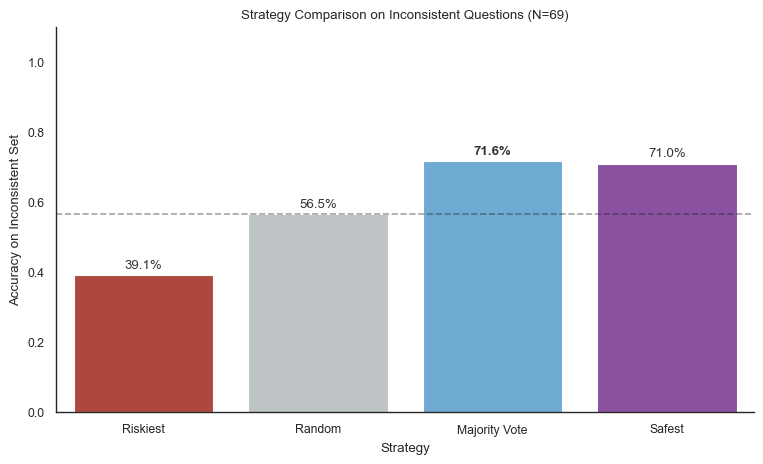

In [8]:
utils.analyze_intra_question_selection_filtered(test_df, cluster_predictor)

In [9]:
utils.plot_pairwise_improvement_table(train_df, cluster_predictor, test_df=test_df)

Strategy Path (Worse ➜ Better),Theoretical 'Expected' Gain,Train Support,Train Gain,Test Support,Test Gain
Cluster 0 34.5% ➜ Cluster 1 80.6%,+46.2%,N=74,+27.0%,N=34,+21.6%
Cluster 0 34.5% ➜ Cluster 2 76.5%,+42.0%,N=62,+25.0%,N=25,+27.3%
Cluster 0 34.5% ➜ Cluster 3 96.1%,+61.6%,N=7,+71.4%,N=3,+33.3%
Cluster 0 34.5% ➜ Cluster 4 95.2%,+60.7%,N=21,+26.2%,N=7,+28.6%
Cluster 2 76.5% ➜ Cluster 1 80.6%,+4.2%,N=164,-1.4%,N=61,-5.7%
Cluster 1 80.6% ➜ Cluster 3 96.1%,+15.4%,N=62,+4.3%,N=25,+18.0%
Cluster 1 80.6% ➜ Cluster 4 95.2%,+14.6%,N=172,+2.9%,N=55,+11.8%
Cluster 2 76.5% ➜ Cluster 3 96.1%,+19.6%,N=31,+9.7%,N=15,+13.3%
Cluster 2 76.5% ➜ Cluster 4 95.2%,+18.7%,N=101,+4.1%,N=31,+5.4%
Cluster 4 95.2% ➜ Cluster 3 96.1%,+0.9%,N=88,-0.4%,N=56,-1.8%


In [10]:
utils.run_full_analysis(train_df,metrics, test_df = test_df);

In [11]:
utils.analyze_outlier_clusters(df)

In [12]:
utils.compare_metric_models(train_df, test_df, {
                                            "Ensemble": ["Entropy", "Length", "Mechanistic", "LogitGap", "Semantic", "Consistency"],
                                            "Mini Ensemble": ["Semantic", "Consistency", "Entropy"],
                                            "Semantic+": ["Semantic", "Consistency"],
                                            "Semantic": ["Semantic"], 
                                          "One shot": ["Entropy", "Length", "Mechanistic", "LogitGap"],
                                          "Entropy+": ["Mechanistic", "Entropy"],
                                          "Entropy": ["Entropy"], 
                                          "Mechanistic": ["Mechanistic"],
                                          "Length": ["Length"], 
                                          "Consistency": ["Consistency"],
                                          "Min Logit Gap": ["LogitGap"]
                                           
                                          });

Configuration,Supervised (LogReg),Unsupervised (Cluster)
"1Mini Ensemble Semantic, Consistency, Entropy",0.926,0.887
"2Ensemble Entropy, Length, Mechanistic, LogitGap, Semantic, Consistency",0.925,0.857
"3Semantic+ Semantic, Consistency",0.917,0.908
4Semantic Semantic,0.911,0.911
"5One shot Entropy, Length, Mechanistic, LogitGap",0.818,0.738
"6Entropy+ Mechanistic, Entropy",0.814,0.780
7Entropy Entropy,0.811,0.777
8Mechanistic Mechanistic,0.767,0.750
9Consistency Consistency,0.749,0.721
10Min Logit Gap LogitGap,0.630,0.606


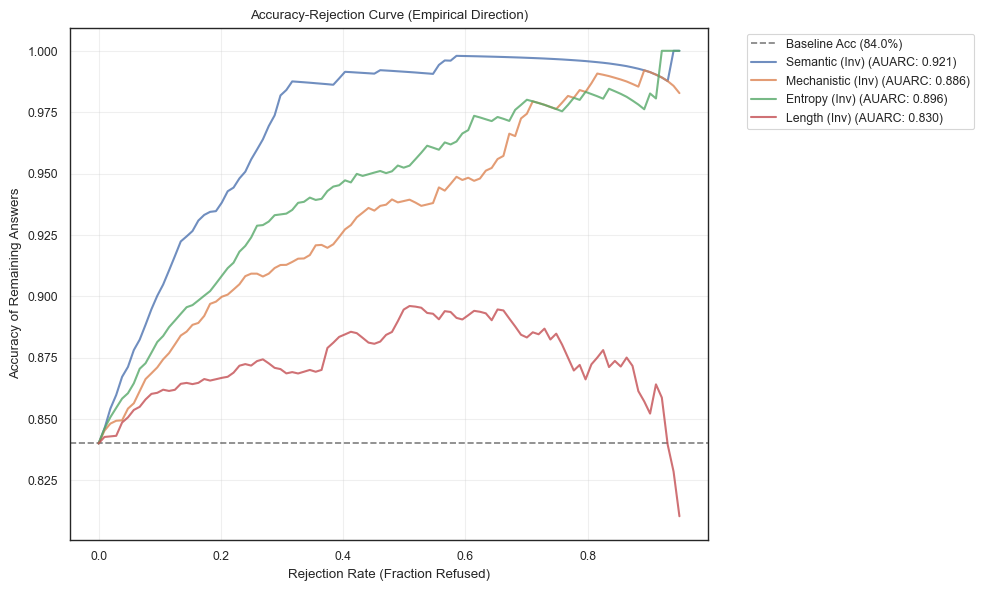

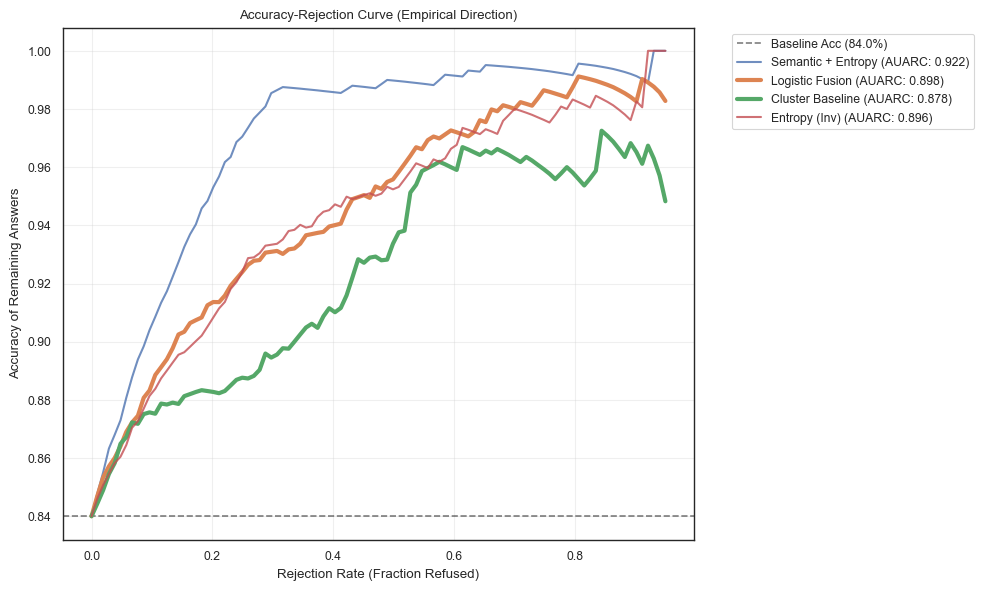

In [13]:
metrics_to_use = ['Entropy', 'LogitGap', 'Mechanistic','Length'] 

logistic_predictor = utils.run_detailed_logistic_regression(train_df, features=metrics_to_use, test_df = test_df, plot = False)

logistic_predictor_semantic_plus = utils.run_detailed_logistic_regression(train_df, features=["Semantic", "Entropy"], test_df = test_df, plot = False)

cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=metrics_to_use, test_df = test_df, min_clusters = 5, plot = False)


for sdf in [train_df, test_df]:
    sdf['Logistic Fusion'], _ = logistic_predictor(sdf)
    sdf['Semantic + Entropy'], _ = logistic_predictor_semantic_plus(sdf)
    _, sdf['Cluster Label'] = cluster_predictor(sdf)

cluster_accs = train_df.groupby('Cluster Label')['Correct'].mean()
test_df['Cluster Baseline'] = test_df['Cluster Label'].map(cluster_accs)

utils.plot_auarc_analysis(test_df, ["Semantic", "Mechanistic", "Entropy", "Length"])
utils.plot_auarc_analysis(test_df, ["Semantic + Entropy", "Logistic Fusion","Cluster Baseline", "Entropy"])

Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,-0.03 SD,0.059,0.055,0.03,
Semantic,+0.19 SD,0.065,0.076,0.19,
Length,-0.69 SD,211.703,211.412,43.27,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,-0.12 SD,0.050,0.052,0.02,
Semantic,+0.27 SD,0.147,0.109,0.23,
Length,+0.91 SD,339.038,341.049,49.21,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+1.32 SD,0.110,0.110,0.05,
Semantic,+2.21 SD,0.907,0.901,0.30,


Generating t-SNE on Train & Test Analysis...


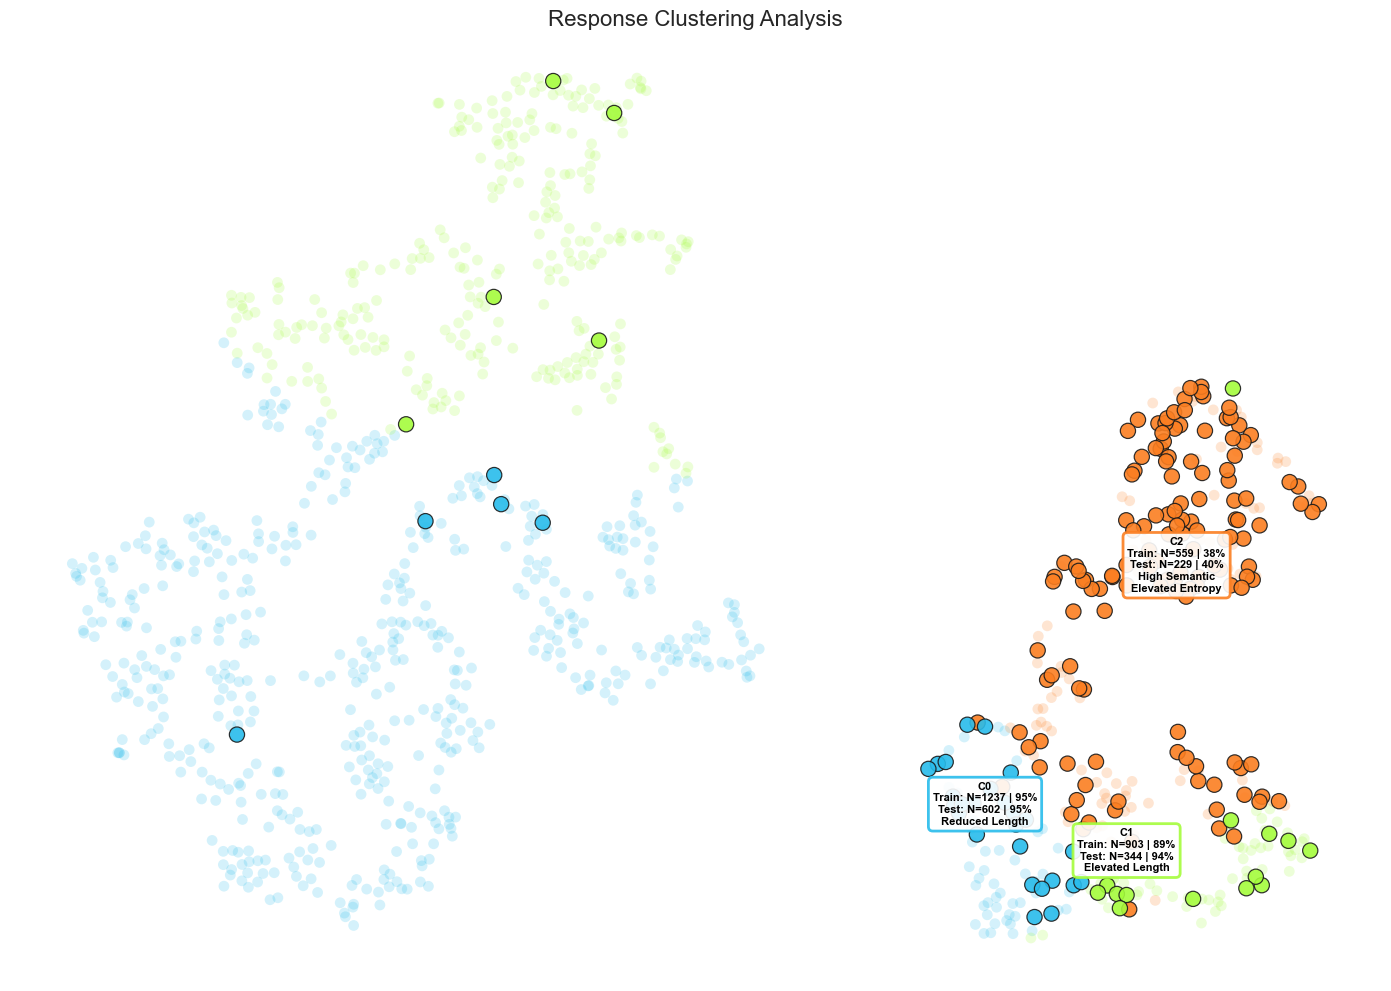

Generating Difficulty Stratification Plots.
Generating Stratified Plots for k=[0, 1, 2, 3, 4]...


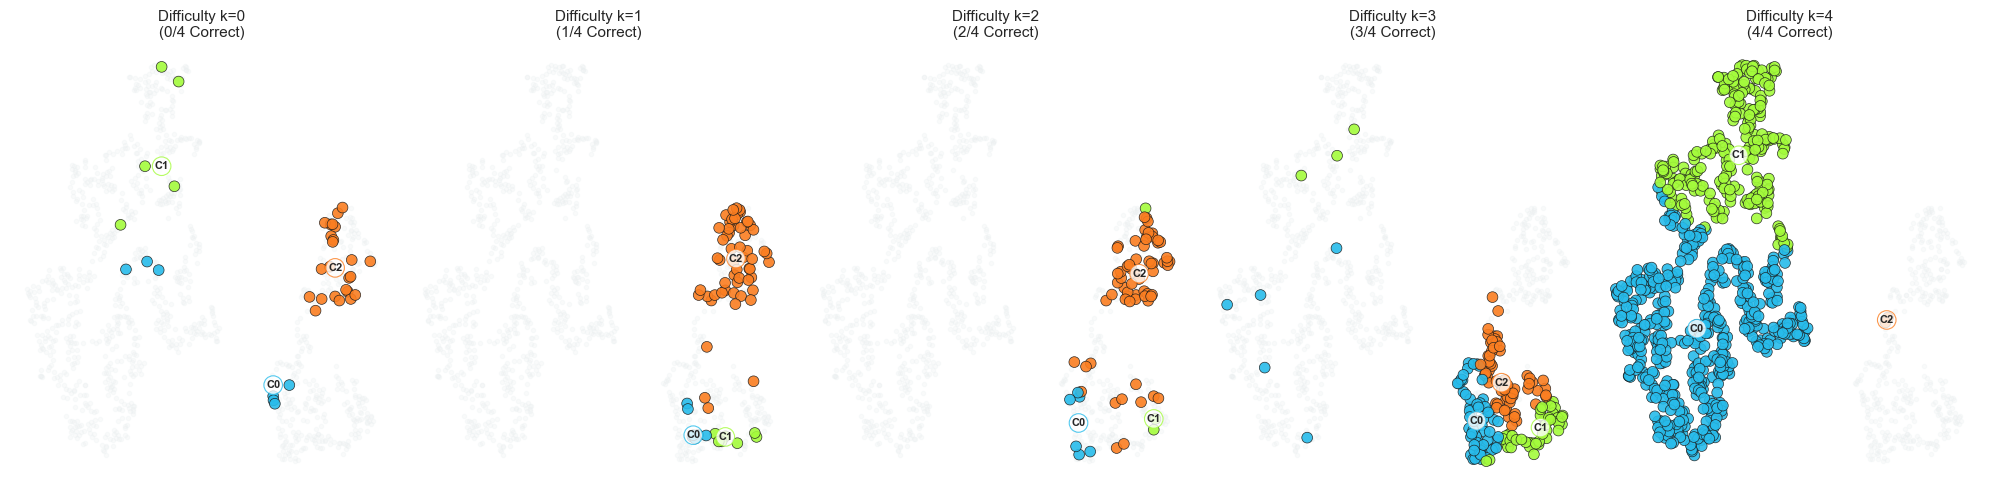

Generating Discrimination Bar Chart.


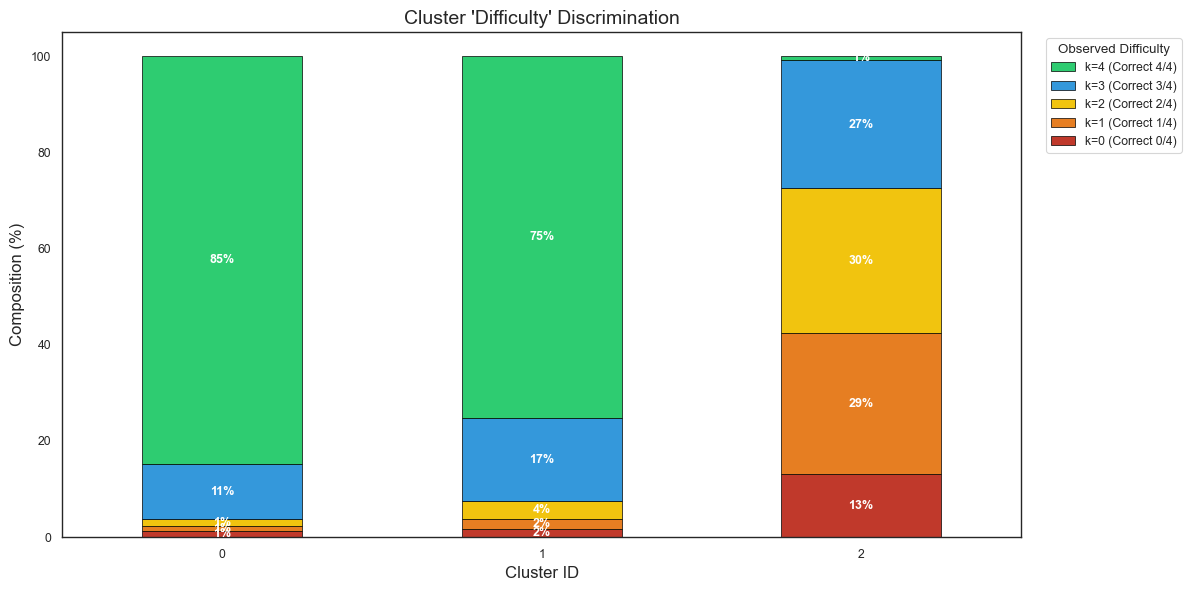


--- Pairwise Cluster Comparison (Same Question Overlap) ---


,Pair,Train_N,Train_Diff,Test_N,Test_Diff
0,C0 (94.5%) vs C1 (89.0%),208,-1.8%,75,-4.2%
1,C0 (94.5%) vs C2 (38.5%),48,+17.4%,20,+20.0%
2,C1 (89.0%) vs C2 (38.5%),59,+26.3%,19,+44.7%


In [14]:
utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy",  "Semantic", "Length"], test_df = test_df, min_clusters = 3)